In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px

sns.set_theme(style="whitegrid")

pd.set_option("display.max_columns", None)

In [4]:
customers = pd.read_csv("../data/raw/olist_customers_dataset.csv")
orders = pd.read_csv("../data/raw/olist_orders_dataset.csv")
order_items = pd.read_csv("../data/raw/olist_order_items_dataset.csv")
payments = pd.read_csv("../data/raw/olist_order_payments_dataset.csv")
products = pd.read_csv("../data/raw/olist_products_dataset.csv")
reviews = pd.read_csv("../data/raw/olist_order_reviews_dataset.csv")

In [5]:
customers.shape

(99441, 5)

In [6]:
datasets={
    "Customers":customers,
    "Orders":orders,
    "Order items":order_items,
    "Payments":payments,
    "Products":products,
    "Reviews":reviews
}

summary = pd.DataFrame({
    "Rows":[df.shape[0] for df in datasets.values()],
    "Columns":[df.shape[1] for df in datasets.values()],
    "Missing values":[df.isnull().sum().sum() for df in datasets.values()]},index=datasets.keys()) 

summary

,Rows,Columns,Missing values
Customers,99441,5,0
Orders,99441,8,4908
Order items,112650,7,0
Payments,103886,5,0
Products,32951,9,2448
Reviews,99224,7,145903


In [7]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


## Customer Analysis
Business Question 1

How many unique customers are there?

In [9]:
customers["customer_unique_id"].nunique()

96096

## There are 96096 customers, indicating a large number of customer base.

Business Question 2

Which states have the most customers?

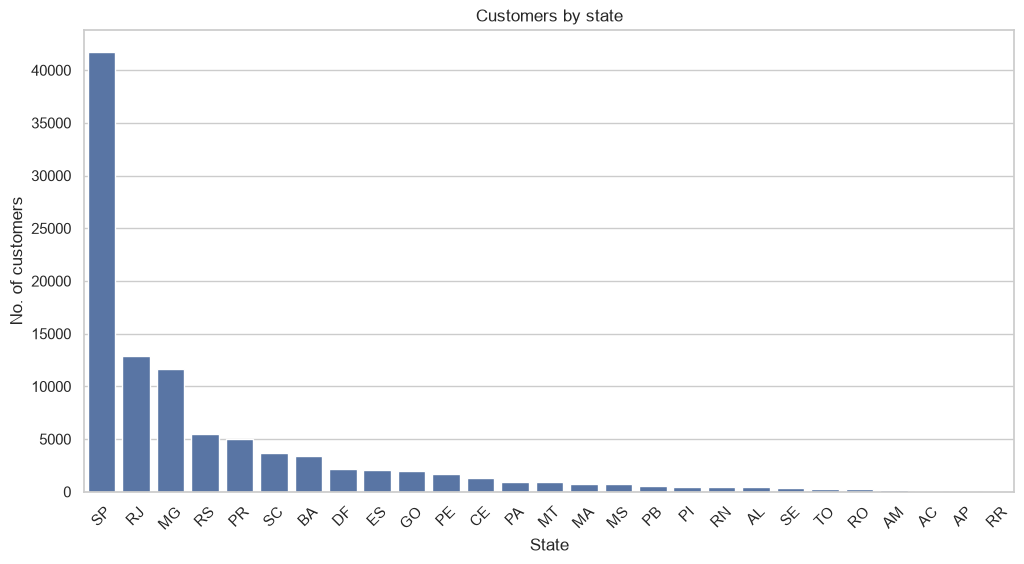

In [12]:
state_count = (customers["customer_state"].value_counts().sort_values(ascending=False))
plt.figure(figsize=(12,6))
sns.barplot(x=state_count.index, y=state_count.values)
plt.title("Customers by state")
plt.xlabel("State")
plt.ylabel("No. of customers")
plt.xticks(rotation=45)
plt.show()

Observation

* São Paulo has the highest number of customers.

Business Insight

* Marketing campaigns should prioritize states with the largest customer base.

Business Action

* Allocate more advertising budget to high-performing states

## Top 10 Cities

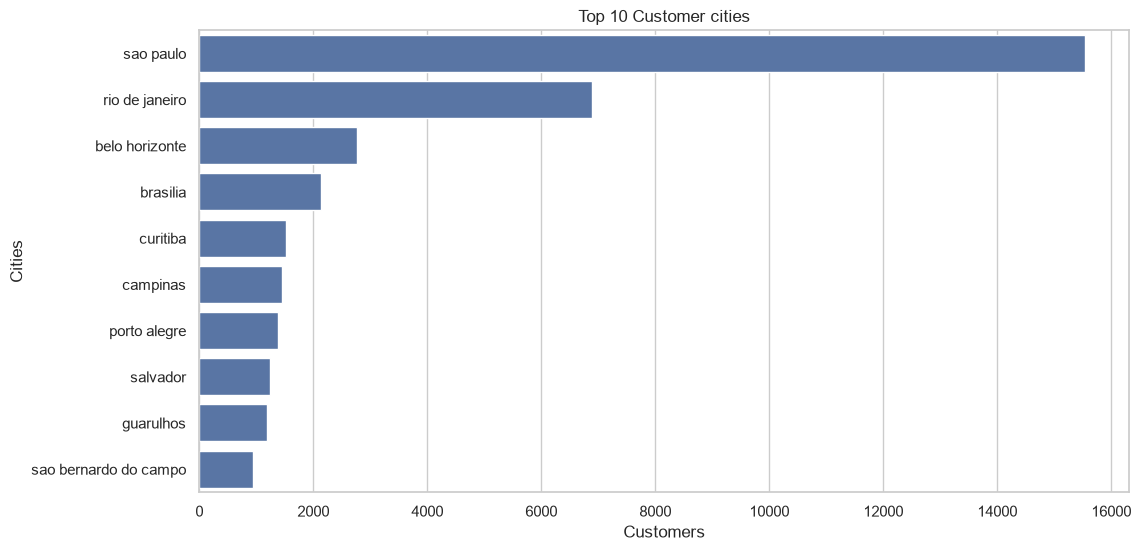

In [15]:
city_counts=customers["customer_city"].value_counts().head(10)
plt.figure(figsize=(12,6))
sns.barplot(x=city_counts.values,
            y=city_counts.index)
plt.title("Top 10 Customer cities")
plt.xlabel("Customers")
plt.ylabel("Cities")
plt.show()

##  Order Status

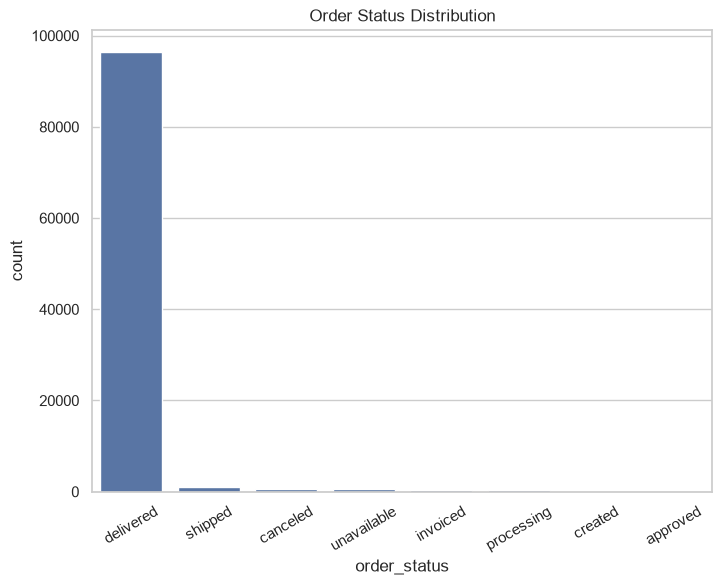

In [25]:
plt.figure(figsize=(8,6))

sns.countplot(
    data=orders,
    x="order_status",
    order=orders["order_status"].value_counts().index
)

plt.title("Order Status Distribution")
plt.xticks(rotation=30)

plt.show()

The delivery process is healthy
there are vey less canceled orders

## Payment Methods

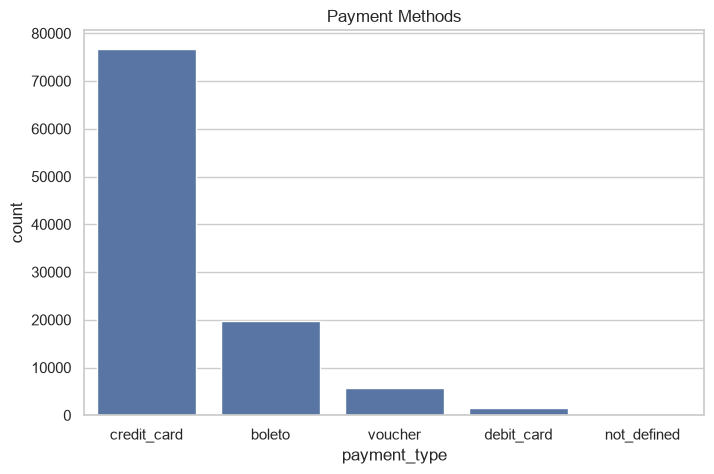

In [27]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=payments,
    x="payment_type",
    order=payments["payment_type"].value_counts().index
)

plt.title("Payment Methods")

plt.show()

The credit card is the most used payment method
This indicates that customers heavily rely or mostly use credit card as primary payment method

## Review Scores

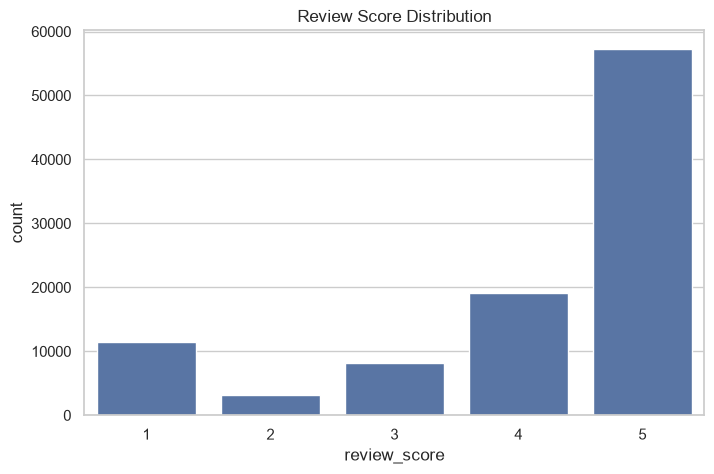

In [29]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=reviews,
    x="review_score"
)

plt.title("Review Score Distribution")

plt.show()

Most customers have given 5 star rating indicating that they are staisfied by the products/service
followed by 4 stars, 1 star, 3 stars and 2 stars